# Object detection: a worked PyTorch companion

Object detection asks two questions at once: **what is present?** and **where is it?** This notebook develops the complete path from bounding-box geometry to a small trainable detector.

Everything is generated locally. There are no downloads, external datasets, or pretrained models. A complete run takes roughly a minute or less on a typical CPU.

### Learning goals

By the end, you should be able to:

1. convert between common box formats and state the coordinate convention;
2. compute IoU and explain what box losses measure;
3. read a detector output tensor of shape $K\times(C+5)$;
4. distinguish assignment, training loss, NMS, and AP evaluation;
5. train and inspect a minimal PyTorch detector.

The final model handles **at most one object per image**. This restriction keeps the code short enough to study; the preceding sections show what must change for multiple objects.

## 0. Setup and conventions

**Requirements:** Python 3.10+, PyTorch 2.x, and Matplotlib. The notebook does not require `torchvision`.

We use half-open corner coordinates $[x_{min},y_{min},x_{max},y_{max}]$. Thus width is $x_{max}-x_{min}$, with no `+1`. Image coordinates start at the top-left: $x$ increases to the right and $y$ increases downward.

In [1]:
import math
import random
import time

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import torch
from torch import nn
import torch.nn.functional as F

SEED = 7
random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(4, torch.get_num_threads()))

torch.set_printoptions(precision=3, sci_mode=False)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

TEAL = "#2A7F7F"
ORANGE = "#F57C00"
BLUE = "#2E6DB4"
GREEN = "#20A84A"
RED = "#D64550"

print(f"PyTorch {torch.__version__}; CPU threads: {torch.get_num_threads()}")

PyTorch 2.13.0; CPU threads: 4


## 1. From pixels to a set of objects

A classifier returns one label for the entire image. A detector returns a **set of records**. Each record contains a class and a box. The number and order of objects are not fixed by the image dimensions.

The synthetic scene below contains two ground-truth objects. The colours are merely class identifiers; no trained model has produced these boxes.

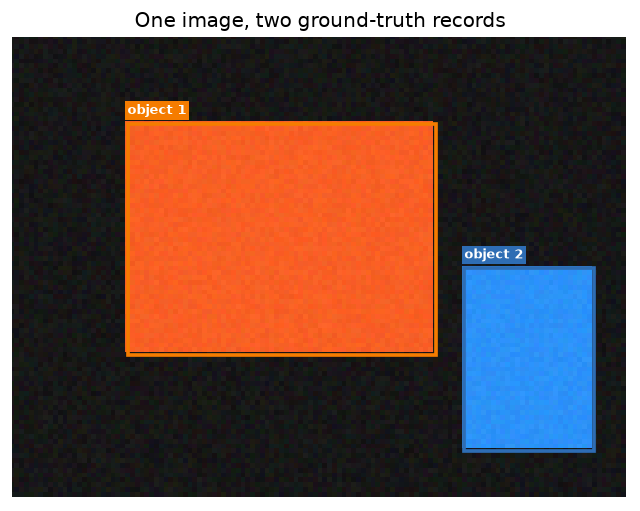

object 1: class=orange object, box xyxy=[24.0, 18.0, 88.0, 66.0]
object 2: class=blue object, box xyxy=[94.0, 48.0, 121.0, 86.0]


In [2]:
def xyxy_to_cxcywh(boxes):
    # Convert [..., xmin, ymin, xmax, ymax] to [..., xc, yc, w, h].
    boxes = torch.as_tensor(boxes, dtype=torch.float32)
    x0, y0, x1, y1 = boxes.unbind(-1)
    return torch.stack(((x0 + x1) / 2, (y0 + y1) / 2, x1 - x0, y1 - y0), dim=-1)


def cxcywh_to_xyxy(boxes):
    # Convert [..., xc, yc, w, h] to [..., xmin, ymin, xmax, ymax].
    boxes = torch.as_tensor(boxes, dtype=torch.float32)
    xc, yc, w, h = boxes.unbind(-1)
    return torch.stack((xc - w / 2, yc - h / 2, xc + w / 2, yc + h / 2), dim=-1)


def draw_boxes(ax, boxes, labels=None, colors=None, linewidth=2.2):
    boxes = torch.as_tensor(boxes).detach().cpu()
    labels = labels or [""] * len(boxes)
    colors = colors or [ORANGE] * len(boxes)
    for box, label, color in zip(boxes, labels, colors):
        x0, y0, x1, y1 = box.tolist()
        ax.add_patch(Rectangle(
            (x0, y0), x1 - x0, y1 - y0,
            fill=False, lw=linewidth, ec=color,
        ))
        if label:
            ax.text(
                x0, max(0, y0 - 2), label,
                color="white", fontsize=8, weight="bold",
                bbox=dict(fc=color, ec="none", pad=1.5),
            )


H, W = 96, 128
g = torch.Generator().manual_seed(4)
scene = torch.rand((3, H, W), generator=g) * 0.06 + 0.06
gt_boxes_px = torch.tensor([
    [24, 18, 88, 66],
    [94, 48, 121, 86],
], dtype=torch.float32)
gt_classes = torch.tensor([0, 1])
class_names = ["orange object", "blue object"]
class_rgb = torch.tensor([[0.95, 0.35, 0.12], [0.15, 0.55, 0.95]])

for box, cls in zip(gt_boxes_px.int(), gt_classes):
    x0, y0, x1, y1 = box.tolist()
    noise = torch.rand((3, y1-y0, x1-x0), generator=g) * 0.05
    scene[:, y0:y1, x0:x1] = class_rgb[cls, :, None, None] + noise

fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(scene.permute(1, 2, 0).clamp(0, 1))
draw_boxes(ax, gt_boxes_px, ["object 1", "object 2"], [ORANGE, BLUE])
ax.set(title="One image, two ground-truth records", xlim=(0, W), ylim=(H, 0))
ax.axis("off")
plt.show()

for i, (box, cls) in enumerate(zip(gt_boxes_px, gt_classes), start=1):
    print(f"object {i}: class={class_names[cls]}, box xyxy={box.tolist()}")

### Worked example: three descriptions of the same box

For the first object, the corner form is $[24,18,88,66]$ in a $128\times96$ image.

1. Centre: $x_c=(24+88)/2=56$, $y_c=(18+66)/2=42$.
2. Size: $w=88-24=64$, $h=66-18=48$.
3. Divide horizontal quantities by $W=128$ and vertical quantities by $H=96$ to normalize.

Normalizing boxes is useful because the target scale no longer depends directly on image resolution.

In [3]:
scale_xyxy = torch.tensor([W, H, W, H], dtype=torch.float32)
scale_cxcywh = torch.tensor([W, H, W, H], dtype=torch.float32)

box_xyxy_px = gt_boxes_px[0]
box_cxcywh_px = xyxy_to_cxcywh(box_xyxy_px)
box_cxcywh_norm = box_cxcywh_px / scale_cxcywh
round_trip = cxcywh_to_xyxy(box_cxcywh_norm * scale_cxcywh)

print("corner form, pixels       ", box_xyxy_px)
print("centre-size, pixels       ", box_cxcywh_px)
print("centre-size, normalized   ", box_cxcywh_norm)
print("round trip to corner form ", round_trip)

assert torch.allclose(box_cxcywh_px, torch.tensor([56., 42., 64., 48.]))
assert torch.allclose(box_cxcywh_norm, torch.tensor([0.4375, 0.4375, 0.5, 0.5]))
assert torch.allclose(round_trip, box_xyxy_px)

corner form, pixels        tensor([24., 18., 88., 66.])
centre-size, pixels        tensor([56., 42., 64., 48.])
centre-size, normalized    tensor([0.438, 0.438, 0.500, 0.500])
round trip to corner form  tensor([24., 18., 88., 66.])


### Worked example: resizing with letterbox padding

A direct resize from $128\times96$ to $160\times160$ would stretch the image. **Letterboxing** first applies a common scale and then pads the shorter dimension.

For source size $(W,H)=(128,96)$ and destination size $(W',H')=(160,160)$:

$$
s=\min\left(\frac{W'}{W},\frac{H'}{H}\right)=1.25.
$$

The resized image is $160\times120$, leaving 40 vertical pixels. With symmetric padding, $p_x=0$ and $p_y=20$. Every corner transforms as

$$
(x',y')=(s x+p_x,\;s y+p_y).
$$

The inverse subtracts the padding and divides by the same scale. Predictions made in letterboxed coordinates must be mapped back before they are reported in source-image coordinates.

scale: 1.25
resized image: (160, 120)
padding (left, top): (0, 20)
source box 0:      tensor([24., 18., 88., 66.])
letterboxed box 0: tensor([ 30.000,  42.500, 110.000, 102.500])
recovered box 0:   tensor([24., 18., 88., 66.])


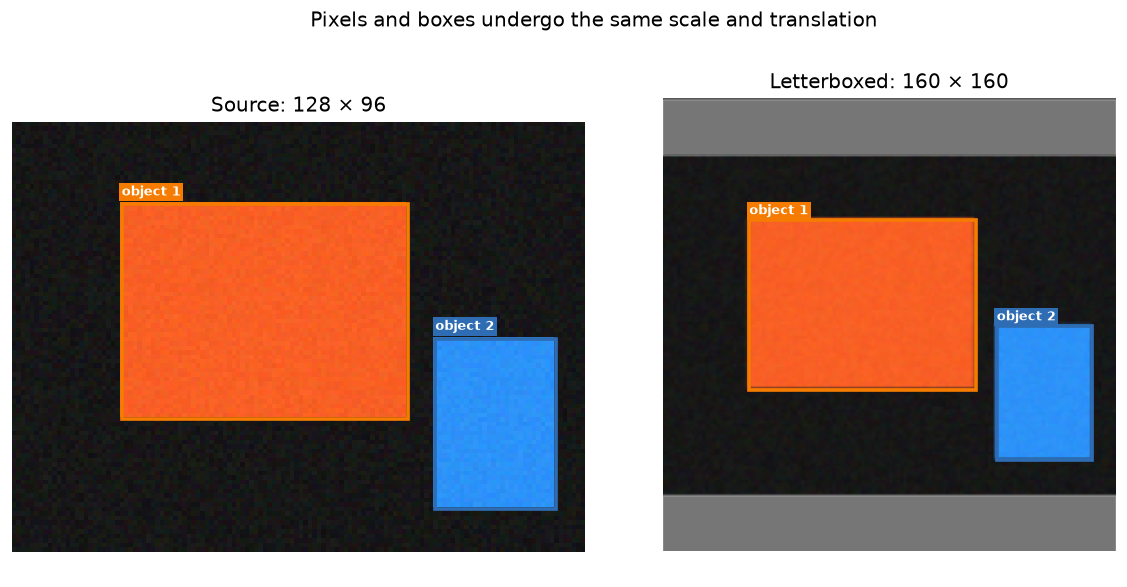

In [4]:
def letterbox_image_and_boxes(image, boxes_xyxy, output_height, output_width, fill=0.35):
    _, source_height, source_width = image.shape
    scale = min(output_width / source_width, output_height / source_height)
    resized_width = round(source_width * scale)
    resized_height = round(source_height * scale)
    pad_left = (output_width - resized_width) // 2
    pad_top = (output_height - resized_height) // 2

    resized = F.interpolate(
        image.unsqueeze(0),
        size=(resized_height, resized_width),
        mode="bilinear",
        align_corners=False,
    )[0]
    canvas = torch.full((image.shape[0], output_height, output_width), fill)
    canvas[:, pad_top:pad_top+resized_height, pad_left:pad_left+resized_width] = resized

    offset = torch.tensor([pad_left, pad_top, pad_left, pad_top], dtype=torch.float32)
    transformed_boxes = boxes_xyxy * scale + offset
    parameters = {
        "scale": scale,
        "pad_left": pad_left,
        "pad_top": pad_top,
        "resized_width": resized_width,
        "resized_height": resized_height,
    }
    return canvas, transformed_boxes, parameters


def undo_letterbox_boxes(boxes_xyxy, scale, pad_left, pad_top):
    offset = torch.tensor([pad_left, pad_top, pad_left, pad_top], dtype=torch.float32)
    return (boxes_xyxy - offset) / scale


letterboxed, boxes_letterboxed, letterbox = letterbox_image_and_boxes(
    scene, gt_boxes_px, output_height=160, output_width=160
)
boxes_recovered = undo_letterbox_boxes(
    boxes_letterboxed,
    letterbox["scale"],
    letterbox["pad_left"],
    letterbox["pad_top"],
)

print("scale:", letterbox["scale"])
print("resized image:", (letterbox["resized_width"], letterbox["resized_height"]))
print("padding (left, top):", (letterbox["pad_left"], letterbox["pad_top"]))
print("source box 0:     ", gt_boxes_px[0])
print("letterboxed box 0:", boxes_letterboxed[0])
print("recovered box 0:  ", boxes_recovered[0])

assert letterbox == {
    "scale": 1.25,
    "pad_left": 0,
    "pad_top": 20,
    "resized_width": 160,
    "resized_height": 120,
}
assert torch.allclose(boxes_recovered, gt_boxes_px, atol=1e-5)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))
axes[0].imshow(scene.permute(1, 2, 0).clamp(0, 1))
draw_boxes(axes[0], gt_boxes_px, ["object 1", "object 2"], [ORANGE, BLUE])
axes[0].set_title("Source: 128 × 96")
axes[0].axis("off")

axes[1].imshow(letterboxed.permute(1, 2, 0).clamp(0, 1))
draw_boxes(axes[1], boxes_letterboxed, ["object 1", "object 2"], [ORANGE, BLUE])
axes[1].axhspan(0, letterbox["pad_top"], color="white", alpha=0.18)
axes[1].axhspan(160-letterbox["pad_top"], 160, color="white", alpha=0.18)
axes[1].set_title("Letterboxed: 160 × 160")
axes[1].axis("off")

fig.suptitle("Pixels and boxes undergo the same scale and translation", y=1.01)
plt.tight_layout()
plt.show()

> **Check 1.** Suppose the image is resized from $128\times96$ to $256\times192$ without cropping or padding. Which representation above stays unchanged? Which values double?

> **Check 2.** Why must a crop, pad, resize, or horizontal flip be applied to the boxes as well as the pixels?

## 2. Intersection over Union (IoU)

IoU measures overlap between two boxes:

$$
\operatorname{IoU}(A,B)=\frac{|A\cap B|}{|A\cup B|}.
$$

It is 1 for identical boxes and 0 for disjoint boxes. IoU is invariant to a common translation or positive rescaling of both boxes.

For $A=[0,0,10,10]$ and $B=[5,5,15,15]$, the intersection is a $5\times5$ square. The union is $100+100-25=175$, so $\operatorname{IoU}=25/175\approx0.143$.

IoU(A, B) = 0.142857


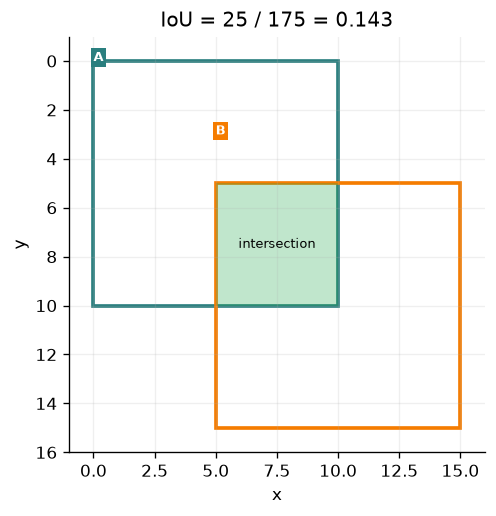

In [5]:
def box_area_xyxy(boxes):
    boxes = torch.as_tensor(boxes, dtype=torch.float32)
    wh = (boxes[..., 2:] - boxes[..., :2]).clamp(min=0)
    return wh[..., 0] * wh[..., 1]


def pairwise_iou(boxes1, boxes2, eps=1e-8):
    # Return an [N, M] IoU matrix for two sets of xyxy boxes.
    boxes1 = torch.as_tensor(boxes1, dtype=torch.float32)
    boxes2 = torch.as_tensor(boxes2, dtype=torch.float32)
    top_left = torch.maximum(boxes1[:, None, :2], boxes2[None, :, :2])
    bottom_right = torch.minimum(boxes1[:, None, 2:], boxes2[None, :, 2:])
    intersection = (bottom_right - top_left).clamp(min=0).prod(dim=-1)
    union = box_area_xyxy(boxes1)[:, None] + box_area_xyxy(boxes2)[None, :] - intersection
    return intersection / union.clamp(min=eps)


A = torch.tensor([[0., 0., 10., 10.]])
B = torch.tensor([[5., 5., 15., 15.]])
iou_ab = pairwise_iou(A, B).item()
print(f"IoU(A, B) = {iou_ab:.6f}")

assert math.isclose(iou_ab, 25 / 175, rel_tol=1e-6)
assert pairwise_iou(A, A).item() == 1.0
assert pairwise_iou(A, torch.tensor([[20., 20., 30., 30.]])).item() == 0.0

fig, ax = plt.subplots(figsize=(5, 4.5))
draw_boxes(ax, torch.cat((A, B)), ["A", "B"], [TEAL, ORANGE])
ax.add_patch(Rectangle((5, 5), 5, 5, fc=GREEN, ec="none", alpha=0.28))
ax.text(7.5, 7.5, "intersection", ha="center", va="center", fontsize=8)
ax.set(xlim=(-1, 16), ylim=(16, -1), aspect="equal", xlabel="x", ylabel="y",
       title=f"IoU = 25 / 175 = {iou_ab:.3f}")
ax.grid(alpha=0.2)
plt.show()

## 3. What do box losses measure?

A coordinate loss and an overlap loss answer related but different questions.

- **Smooth $L_1$** penalizes errors in the chosen parameterization. Its scale therefore depends on whether we use pixels, normalized coordinates, or anchor offsets.
- **IoU loss**, $1-\operatorname{IoU}$, measures the final geometry. However, it is flat when boxes do not overlap.
- **Generalized IoU (GIoU)** adds a penalty based on the smallest enclosing box, so separated boxes can still receive a useful signal.

Modern detectors use several variants, including GIoU, DIoU, and CIoU. The appropriate choice depends on the box parameterization and architecture.

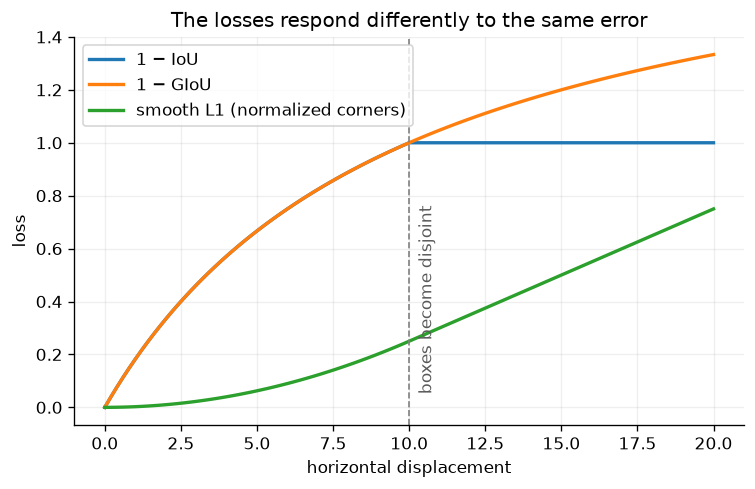

In [6]:
def aligned_iou_xyxy(boxes1, boxes2, eps=1e-8):
    # IoU for aligned pairs: boxes1[i] is compared only with boxes2[i].
    top_left = torch.maximum(boxes1[..., :2], boxes2[..., :2])
    bottom_right = torch.minimum(boxes1[..., 2:], boxes2[..., 2:])
    intersection = (bottom_right - top_left).clamp(min=0).prod(dim=-1)
    union = box_area_xyxy(boxes1) + box_area_xyxy(boxes2) - intersection
    return intersection / union.clamp(min=eps)


def aligned_giou_xyxy(boxes1, boxes2, eps=1e-8):
    iou = aligned_iou_xyxy(boxes1, boxes2, eps)
    enclosing_tl = torch.minimum(boxes1[..., :2], boxes2[..., :2])
    enclosing_br = torch.maximum(boxes1[..., 2:], boxes2[..., 2:])
    enclosing_area = (enclosing_br - enclosing_tl).clamp(min=0).prod(dim=-1)

    top_left = torch.maximum(boxes1[..., :2], boxes2[..., :2])
    bottom_right = torch.minimum(boxes1[..., 2:], boxes2[..., 2:])
    intersection = (bottom_right - top_left).clamp(min=0).prod(dim=-1)
    union = box_area_xyxy(boxes1) + box_area_xyxy(boxes2) - intersection
    return iou - (enclosing_area - union) / enclosing_area.clamp(min=eps)


shifts = torch.linspace(0, 20, 101)
target = torch.tensor([0., 0., 10., 10.]).expand(len(shifts), -1)
prediction = torch.stack((shifts, torch.zeros_like(shifts), shifts + 10, torch.full_like(shifts, 10)), dim=1)

iou_loss = 1 - aligned_iou_xyxy(prediction, target)
giou_loss = 1 - aligned_giou_xyxy(prediction, target)
smooth_l1 = F.smooth_l1_loss(prediction / 10, target / 10, reduction="none").mean(dim=1)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(shifts, iou_loss, lw=2, label="1 − IoU")
ax.plot(shifts, giou_loss, lw=2, label="1 − GIoU")
ax.plot(shifts, smooth_l1, lw=2, label="smooth L1 (normalized corners)")
ax.axvline(10, color="0.5", ls="--", lw=1)
ax.text(10.3, 0.05, "boxes become disjoint", rotation=90, va="bottom", color="0.35")
ax.set(xlabel="horizontal displacement", ylabel="loss", title="The losses respond differently to the same error")
ax.grid(alpha=0.2)
ax.legend()
plt.show()

> **Check 3.** Once the boxes are disjoint, why can $1-\mathrm{IoU}$ no longer distinguish a displacement of 11 pixels from 20 pixels?

> **Exercise.** Change the predicted box size as well as its position. Compare the three curves again. Which loss is most sensitive to the scale error?

## 4. Reading a detector output tensor

Suppose a detector reserves $K$ records for every image and recognizes $C$ foreground classes. One simple record contains:

$$
\underbrace{1}_{\text{objectness}}+
\underbrace{4}_{\text{box}}+
\underbrace{C}_{\text{class logits}}
= C+5 \quad\text{numbers}.
$$

The full output has shape $K\times(C+5)$. Here:

- $K$ is the number of candidate records reserved for an image;
- $C$ is the number of foreground classes;
- the additional five values are one objectness logit and four box values.

This is a teaching representation, not a universal API. YOLO, RetinaNet, Faster R-CNN, and DETR arrange these quantities differently, but the same three semantic parts remain.

In [7]:
K, C = 5, 2
raw_records = torch.tensor([
    [ 2.8, -0.2,  0.1,  0.4,  0.2,  2.1, -0.8],
    [ 1.9,  0.6, -0.5, -0.1,  0.3,  1.5, -0.2],
    [ 2.3, -0.4,  0.8,  0.0, -0.2, -0.3,  1.8],
    [-1.5,  0.1,  0.3, -0.6, -0.1,  0.4,  0.2],
    [-2.2, -0.7, -0.4,  0.2,  0.5, -0.1,  0.1],
], dtype=torch.float32)

objectness_logits = raw_records[:, 0]
box_parameters = raw_records[:, 1:5]
class_logits = raw_records[:, 5:]

objectness = objectness_logits.sigmoid()
decoded_cxcywh = box_parameters.sigmoid()  # deliberately simple for this example
class_probability = class_logits.softmax(dim=1)
class_confidence, predicted_class = class_probability.max(dim=1)
detection_score = objectness * class_confidence

print("raw tensor shape:", tuple(raw_records.shape), f"= K × (C + 5) = {K} × {C + 5}")
print("splits:", tuple(objectness_logits.shape), tuple(box_parameters.shape), tuple(class_logits.shape))
print("\nrecord  p(object)  predicted class  p(class|object)  product score")
for k in range(K):
    print(f"  {k:>2}       {objectness[k]:.3f}            {predicted_class[k]}             "
          f"{class_confidence[k]:.3f}          {detection_score[k]:.3f}")

assert raw_records.shape == (K, C + 5)
assert box_parameters.shape == (K, 4)

raw tensor shape: (5, 7) = K × (C + 5) = 5 × 7
splits: (5,) (5, 4) (5, 2)

record  p(object)  predicted class  p(class|object)  product score
   0       0.943            0             0.948          0.894
   1       0.870            0             0.846          0.736
   2       0.909            1             0.891          0.810
   3       0.182            0             0.550          0.100
   4       0.100            1             0.550          0.055


Two details are easy to miss:

1. **Empty records are represented by low objectness.** The class logits need not include a background class in this formulation.
2. **The final ranking score often combines objectness and class confidence.** Exact scoring conventions vary across detector families.

> **Check 4.** If $C=20$ and $K=300$, what is the output shape? How many of these records may correspond to real objects in a sparse image?

## 5. Assignment: deciding which record learns which object

Before computing box and class losses, training must decide which candidate record is responsible for each ground-truth object. The small example below uses one-to-one greedy matching by IoU.

This rule is intentionally simple. Practical detectors may use anchor thresholds, centre sampling, optimal transport, bipartite matching, or task-aligned scores. The purpose here is to make the supervision masks explicit.

IoU matrix: rows are candidate records; columns are ground-truth objects
tensor([[0.835, 0.000],
        [0.382, 0.000],
        [0.000, 0.807],
        [0.000, 0.528],
        [0.000, 0.000]])


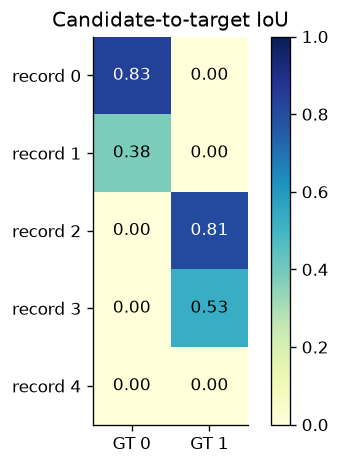

In [8]:
candidate_boxes = torch.tensor([
    [0.10, 0.16, 0.40, 0.56],  # close to ground truth 0
    [0.05, 0.10, 0.27, 0.43],  # weaker candidate for ground truth 0
    [0.57, 0.37, 0.88, 0.78],  # close to ground truth 1
    [0.53, 0.30, 0.82, 0.70],  # weaker candidate for ground truth 1
    [0.40, 0.08, 0.64, 0.30],  # background
])
target_boxes = torch.tensor([
    [0.08, 0.15, 0.38, 0.55],
    [0.55, 0.35, 0.90, 0.80],
])
target_classes = torch.tensor([0, 1])

iou_matrix = pairwise_iou(candidate_boxes, target_boxes)
print("IoU matrix: rows are candidate records; columns are ground-truth objects")
print(iou_matrix)

fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = ax.imshow(iou_matrix, vmin=0, vmax=1, cmap="YlGnBu")
for i in range(iou_matrix.shape[0]):
    for j in range(iou_matrix.shape[1]):
        ax.text(j, i, f"{iou_matrix[i, j]:.2f}", ha="center", va="center",
                color="white" if iou_matrix[i, j] > 0.55 else "black")
ax.set(xticks=range(2), xticklabels=["GT 0", "GT 1"],
       yticks=range(K), yticklabels=[f"record {k}" for k in range(K)],
       title="Candidate-to-target IoU")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.show()

In [9]:
def greedy_one_to_one_assignment(iou_matrix, minimum_iou=0.30):
    # Return {candidate_index: target_index}, highest-IoU pairs first.
    flat_order = torch.argsort(iou_matrix.flatten(), descending=True)
    used_candidates, used_targets, matches = set(), set(), {}
    n_targets = iou_matrix.shape[1]
    for flat_index in flat_order.tolist():
        candidate = flat_index // n_targets
        target = flat_index % n_targets
        if iou_matrix[candidate, target] < minimum_iou:
            break
        if candidate not in used_candidates and target not in used_targets:
            matches[candidate] = target
            used_candidates.add(candidate)
            used_targets.add(target)
    return matches


matches = greedy_one_to_one_assignment(iou_matrix)
positive_mask = torch.zeros(K, dtype=torch.bool)
for record, target_index in matches.items():
    positive_mask[record] = True
    print(f"record {record} → ground truth {target_index} "
          f"(IoU {iou_matrix[record, target_index]:.3f})")
print("background records:", torch.where(~positive_mask)[0].tolist())

assert matches == {0: 0, 2: 1}

record 0 → ground truth 0 (IoU 0.835)
record 2 → ground truth 1 (IoU 0.807)
background records: [1, 3, 4]


### Loss masking follows the assignment

- **Objectness loss:** all $K$ records contribute; positives target 1 and background records target 0.
- **Box loss:** only positive records contribute.
- **Class loss:** only positive records contribute.

Without these masks, empty records would be trained toward arbitrary classes and boxes.

In [10]:
object_target = positive_mask.float()
matched_records = torch.tensor(sorted(matches))
matched_targets = torch.tensor([matches[k] for k in sorted(matches)])

objectness_loss = F.binary_cross_entropy_with_logits(objectness_logits, object_target)
class_loss = F.cross_entropy(class_logits[matched_records], target_classes[matched_targets])
box_targets_cxcywh = xyxy_to_cxcywh(target_boxes[matched_targets])
box_loss = F.smooth_l1_loss(decoded_cxcywh[matched_records], box_targets_cxcywh)

lambda_box = 5.0
total_loss = objectness_loss + class_loss + lambda_box * box_loss

print(f"objectness BCE            = {objectness_loss:.4f}  (all {K} records)")
print(f"classification CE         = {class_loss:.4f}  ({len(matches)} positive records)")
print(f"smooth-L1 box loss        = {box_loss:.4f}  ({len(matches)} positive records)")
print(f"total = obj + cls + 5 box = {total_loss:.4f}")

objectness BCE            = 0.5001  (all 5 records)
classification CE         = 0.0845  (2 positive records)
smooth-L1 box loss        = 0.0207  (2 positive records)
total = obj + cls + 5 box = 0.6881


> **Check 5.** A detector reserves 1,000 records and an image contains three objects. How many records contribute to objectness, box regression, and classification in this simplified rule?

> **Exercise.** Increase `minimum_iou` to 0.8. Which targets lose their assignment? What would the model learn from an object that receives no positive record?

## 6. Non-Maximum Suppression (NMS)

At inference time, several records may describe the same object. Greedy NMS repeatedly:

1. keeps the highest-scoring remaining box;
2. removes lower-scoring boxes of the **same class** whose IoU with it exceeds a threshold;
3. continues until no boxes remain.

NMS is an inference procedure. It does not create training assignments and it is not part of AP matching. In a batch, run it independently for each image; in the usual class-aware form, split each image's boxes by predicted class before comparing IoU.

kept: ['A', 'C', 'D']
suppressed: ['B', 'E']


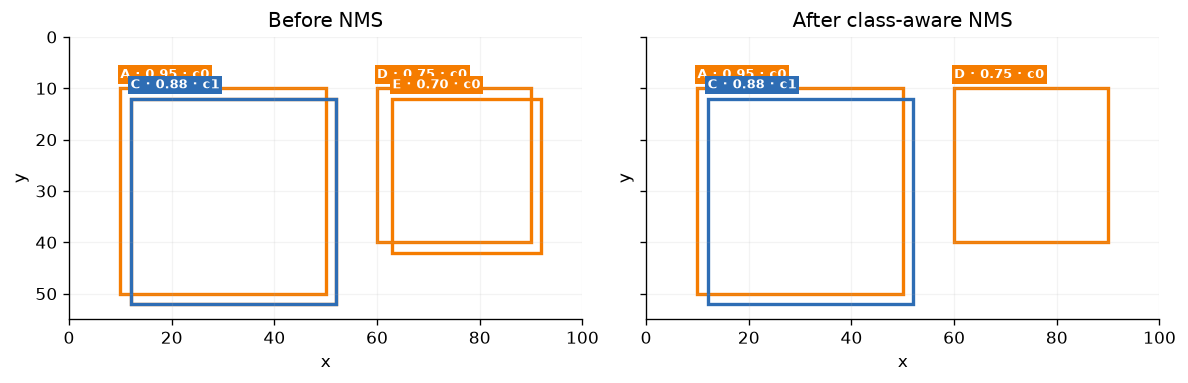

In [11]:
def nms(boxes, scores, iou_threshold=0.5):
    order = torch.argsort(scores, descending=True)
    keep = []
    while order.numel() > 0:
        current = order[0]
        keep.append(current.item())
        if order.numel() == 1:
            break
        remaining = order[1:]
        overlaps = pairwise_iou(boxes[current].unsqueeze(0), boxes[remaining])[0]
        order = remaining[overlaps <= iou_threshold]
    return torch.tensor(keep, dtype=torch.long)


def class_aware_nms(boxes, scores, classes, iou_threshold=0.5):
    kept = []
    for cls in classes.unique(sorted=True):
        members = torch.where(classes == cls)[0]
        local_keep = nms(boxes[members], scores[members], iou_threshold)
        kept.extend(members[local_keep].tolist())
    return torch.tensor(sorted(kept, key=lambda i: scores[i], reverse=True))


nms_boxes = torch.tensor([
    [10, 10, 50, 50],  # A, class 0
    [12, 12, 52, 52],  # B, duplicate of A, class 0
    [12, 12, 52, 52],  # C, same geometry but class 1
    [60, 10, 90, 40],  # D, class 0
    [63, 12, 92, 42],  # E, duplicate of D, class 0
], dtype=torch.float32)
nms_scores = torch.tensor([0.95, 0.90, 0.88, 0.75, 0.70])
nms_classes = torch.tensor([0, 0, 1, 0, 0])
nms_names = ["A", "B", "C", "D", "E"]

kept = class_aware_nms(nms_boxes, nms_scores, nms_classes, iou_threshold=0.5)
print("kept:", [nms_names[i] for i in kept.tolist()])
print("suppressed:", [nms_names[i] for i in range(len(nms_names)) if i not in kept.tolist()])
assert [nms_names[i] for i in kept.tolist()] == ["A", "C", "D"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharex=True, sharey=True)
for ax, indices, title in [
    (axes[0], range(len(nms_boxes)), "Before NMS"),
    (axes[1], kept.tolist(), "After class-aware NMS"),
]:
    boxes = nms_boxes[list(indices)]
    names = [f"{nms_names[i]} · {nms_scores[i]:.2f} · c{nms_classes[i]}" for i in indices]
    colors = [ORANGE if nms_classes[i] == 0 else BLUE for i in indices]
    draw_boxes(ax, boxes, names, colors, linewidth=2)
    ax.set(xlim=(0, 100), ylim=(55, 0), aspect="equal", title=title, xlabel="x", ylabel="y")
    ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

Box C survives even though it exactly overlaps B because it belongs to a different class. This is why class-aware NMS is applied separately to each image and class. Boxes from different images are never compared, and an overlapping box from another class is not suppressed.

> **Exercise.** Sweep the IoU threshold from 0.3 to 0.9. Record the boxes that survive. Explain why neither an extremely low nor an extremely high threshold is satisfactory.

## 7. Average Precision (AP): ranking after inference

Evaluation begins with a frozen, score-ranked list of detections. This list should be broad enough to trace the precision–recall curve; it should not be truncated at the deployment operating threshold. For one class and one IoU threshold:

1. each detection may claim at most one unmatched ground-truth box in the same image;
2. a valid claim is a true positive; otherwise it is a false positive;
3. cumulative precision and recall are recomputed after every rank.

The worked example uses two images and two ground-truth objects. Detection B is a duplicate: the relevant truth has already been claimed by A.

**Deployment and AP use scores differently.** A deployed system chooses a score threshold to meet a desired precision, recall, latency, or alert-volume target, and returns only detections above that operating threshold. AP instead sweeps the ranking: retain a broad list (subject only to a documented low score floor or maximum-detections rule) so that low-scoring true positives can contribute at high recall. Applying the deployment threshold before AP would hide part of the curve.


rank  name  image  score  best eligible IoU  result  precision  recall
  1    A      0    0.95       1.000       TP      1.000     0.500
  2    B      0    0.90       0.819       FP      0.500     0.500
  3    C      1    0.80       0.853       TP      0.667     1.000
  4    D      1    0.70       0.000       FP      0.500     1.000

rank AP@0.50 = 0.833


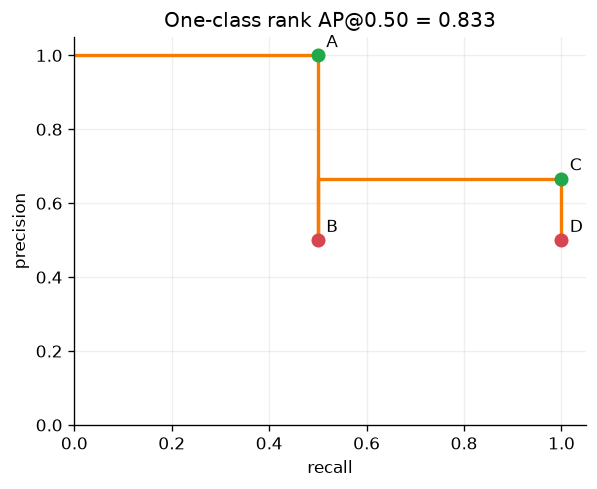

In [12]:
eval_gt = {
    0: torch.tensor([[0.10, 0.10, 0.40, 0.40]]),
    1: torch.tensor([[0.55, 0.50, 0.85, 0.85]]),
}
eval_names = ["A", "B", "C", "D"]
eval_images = torch.tensor([0, 0, 1, 1])
eval_scores = torch.tensor([0.95, 0.90, 0.80, 0.70])
eval_boxes = torch.tensor([
    [0.10, 0.10, 0.40, 0.40],  # A: TP
    [0.12, 0.12, 0.41, 0.41],  # B: duplicate, therefore FP
    [0.57, 0.51, 0.86, 0.84],  # C: TP
    [0.05, 0.55, 0.30, 0.90],  # D: FP
])


def match_ranked_detections(boxes, scores, image_ids, gt_by_image, threshold=0.5):
    order = torch.argsort(scores, descending=True)
    matched = {image_id: set() for image_id in gt_by_image}
    true_positive = []
    best_ious = []

    for index in order.tolist():
        image_id = int(image_ids[index])
        truths = gt_by_image.get(image_id, torch.empty((0, 4)))
        if len(truths) == 0:
            true_positive.append(False)
            best_ious.append(0.0)
            continue

        overlaps = pairwise_iou(boxes[index:index+1], truths)[0]
        available = [j for j in range(len(truths)) if j not in matched[image_id]]
        if not available:
            true_positive.append(False)
            best_ious.append(float(overlaps.max()))
            continue

        best = max(available, key=lambda j: float(overlaps[j]))
        valid = float(overlaps[best]) >= threshold
        true_positive.append(valid)
        best_ious.append(float(overlaps[best]))
        if valid:
            matched[image_id].add(best)

    return order, torch.tensor(true_positive), torch.tensor(best_ious)


order, is_tp, best_ious = match_ranked_detections(
    eval_boxes, eval_scores, eval_images, eval_gt, threshold=0.5
)
tp_cumulative = is_tp.cumsum(0)
fp_cumulative = (~is_tp).cumsum(0)
precision = tp_cumulative / (tp_cumulative + fp_cumulative)
recall = tp_cumulative / sum(len(v) for v in eval_gt.values())

print("rank  name  image  score  best eligible IoU  result  precision  recall")
for rank, (index, tp, overlap, p, r) in enumerate(
    zip(order, is_tp, best_ious, precision, recall), start=1
):
    result = "TP" if tp else "FP"
    print(f" {rank:>2}    {eval_names[index]}      {eval_images[index]}    {eval_scores[index]:.2f}"
          f"       {overlap:.3f}       {result}      {p:.3f}     {r:.3f}")

# Rank AP@0.50 for this one-class example: mean precision at TP ranks.
rank_ap = precision[is_tp].sum() / sum(len(v) for v in eval_gt.values())
print(f"\nrank AP@0.50 = {rank_ap:.3f}")
assert torch.allclose(rank_ap, torch.tensor(5 / 6), atol=1e-6)

fig, ax = plt.subplots(figsize=(5.5, 4.2))
ax.step(torch.cat((torch.tensor([0.]), recall)),
        torch.cat((torch.tensor([1.]), precision)), where="pre", lw=2, color=ORANGE)
for rank, (r, p, tp) in enumerate(zip(recall, precision, is_tp), start=1):
    ax.scatter(r, p, s=55, color=GREEN if tp else RED, zorder=3)
    ax.annotate(eval_names[order[rank-1]], (r, p), xytext=(5, 5), textcoords="offset points")
ax.set(xlim=(0, 1.05), ylim=(0, 1.05), xlabel="recall", ylabel="precision",
       title=f"One-class rank AP@0.50 = {rank_ap:.3f}")
ax.grid(alpha=0.2)
plt.show()

This notebook's rank AP is deliberately transparent, but it is not the complete COCO metric. The ranking is evaluated before selecting any deployment operating point. COCO-style mAP interpolates precision at 101 recall levels, averages over classes, and then averages over IoU thresholds from 0.50 to 0.95.

> **Check 6.** If B's score fell below C's, recall would reach 1 before the duplicate appears. Would AP increase, decrease, or remain unchanged?

> **Exercise.** Recompute the example at IoU thresholds 0.50, 0.75, and 0.90. Explain why stricter thresholds emphasize localization quality.

## 8. A minimal trainable detector in PyTorch

We now train a complete, small model. Each $32\times32$ image contains either:

- no object;
- one orange object (class 0); or
- one blue object (class 1).

The detector reserves one record, so $K=1$ and $C=2$. Its seven outputs are:

$$
[\text{objectness logit},\; x_c,y_c,w,h,\; \text{two class logits}].
$$

This example includes the essential ingredients—backbone, detection head, masked loss, optimization, and evaluation—without the additional bookkeeping required for multiple objects.

In [13]:
IMAGE_SIZE = 32
NUM_CLASSES = 2
SYNTHETIC_COLORS = torch.tensor([
    [0.95, 0.20, 0.15],
    [0.15, 0.55, 0.95],
])


def make_detection_dataset(n, seed, empty_probability=0.20):
    generator = torch.Generator().manual_seed(seed)
    images = torch.rand((n, 3, IMAGE_SIZE, IMAGE_SIZE), generator=generator) * 0.06
    object_target = (torch.rand(n, generator=generator) > empty_probability)
    box_target = torch.zeros((n, 4), dtype=torch.float32)  # normalized cxcywh
    class_target = torch.zeros(n, dtype=torch.long)

    for i in range(n):
        if not object_target[i]:
            continue
        cls = int(torch.randint(0, NUM_CLASSES, (1,), generator=generator))
        width = int(torch.randint(7, 15, (1,), generator=generator))
        height = int(torch.randint(7, 15, (1,), generator=generator))
        x0 = int(torch.randint(1, IMAGE_SIZE - width, (1,), generator=generator))
        y0 = int(torch.randint(1, IMAGE_SIZE - height, (1,), generator=generator))

        colour = SYNTHETIC_COLORS[cls, :, None, None]
        texture = torch.rand((3, height, width), generator=generator) * 0.04
        images[i, :, y0:y0+height, x0:x0+width] = colour + texture
        box_target[i] = torch.tensor([
            (x0 + width / 2) / IMAGE_SIZE,
            (y0 + height / 2) / IMAGE_SIZE,
            width / IMAGE_SIZE,
            height / IMAGE_SIZE,
        ])
        class_target[i] = cls

    return images.clamp(0, 1), object_target.float(), box_target, class_target


X_train, y_obj_train, y_box_train, y_cls_train = make_detection_dataset(320, seed=11)
X_test, y_obj_test, y_box_test, y_cls_test = make_detection_dataset(128, seed=99)

print("training images:", tuple(X_train.shape))
print("positive / empty:", int(y_obj_train.sum()), "/", int((1 - y_obj_train).sum()))
print("box targets:", tuple(y_box_train.shape), "(normalized cxcywh)")

training images: (320, 3, 32, 32)


positive / empty: 267 / 53
box targets: (320, 4) (normalized cxcywh)


In [14]:
class TinyDetector(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                          # 32 → 16
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                          # 16 → 8
            nn.Conv2d(32, 48, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                          # 8 → 4
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(48 * 4 * 4, 64),
            nn.ReLU(),
            nn.Linear(64, 1 + 4 + num_classes),
        )

    def forward(self, images):
        features = self.backbone(images)
        return self.head(features)


model = TinyDetector(NUM_CLASSES)
with torch.no_grad():
    example_output = model(X_train[:4])

print(model)
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")
print("batch output:", tuple(example_output.shape), "= [B, 1 + 4 + C]")
assert example_output.shape == (4, 7)

TinyDetector(
  (backbone): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=768, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=7, bias=True)
  )
)
parameters: 68,631
batch output: (4, 7) = [B, 1 + 4 + C]


### The loss is the same decomposition used earlier

For a mini-batch:

$$
\mathcal{L}=\mathcal{L}_{obj}+\mathcal{L}_{cls}+8\mathcal{L}_{box}.
$$

Objectness uses every image. Classification and box regression use only images that contain an object. The factor 8 places the three terms on comparable numerical scales for this toy problem; it is a hyperparameter, not a mathematical constant.

In [15]:
def detection_loss(raw_output, object_target, box_target, class_target):
    object_logits = raw_output[:, 0]
    box_prediction = raw_output[:, 1:5].sigmoid()  # normalized cxcywh
    class_logits = raw_output[:, 5:]
    positive = object_target.bool()

    loss_object = F.binary_cross_entropy_with_logits(object_logits, object_target)
    if positive.any():
        loss_box = F.smooth_l1_loss(box_prediction[positive], box_target[positive])
        loss_class = F.cross_entropy(class_logits[positive], class_target[positive])
    else:
        zero = raw_output.sum() * 0.0
        loss_box = zero
        loss_class = zero

    total = loss_object + loss_class + 8.0 * loss_box
    return total, {"objectness": loss_object, "class": loss_class, "8 × box": 8.0 * loss_box}


torch.manual_seed(SEED)
model = TinyDetector(NUM_CLASSES)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3, weight_decay=1e-4)
batch_size = 64
epochs = 50
shuffle_generator = torch.Generator().manual_seed(123)
history = {"total": [], "objectness": [], "class": [], "8 × box": []}

start = time.perf_counter()
model.train()
for epoch in range(epochs):
    permutation = torch.randperm(len(X_train), generator=shuffle_generator)
    running = {name: 0.0 for name in history}

    for indices in permutation.split(batch_size):
        raw = model(X_train[indices])
        loss, parts = detection_loss(
            raw,
            y_obj_train[indices],
            y_box_train[indices],
            y_cls_train[indices],
        )
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running["total"] += float(loss.detach()) * len(indices)
        for name, value in parts.items():
            running[name] += float(value.detach()) * len(indices)

    for name in history:
        history[name].append(running[name] / len(X_train))

training_seconds = time.perf_counter() - start
print(f"trained for {epochs} epochs in {training_seconds:.2f} s")
print(f"initial total loss: {history['total'][0]:.4f}")
print(f"final total loss:   {history['total'][-1]:.4f}")

trained for 50 epochs in 4.58 s
initial total loss: 1.3529
final total loss:   0.0017


test objectness accuracy: 1.000
test class accuracy:      1.000
test mean IoU:            0.772
test median IoU:          0.800


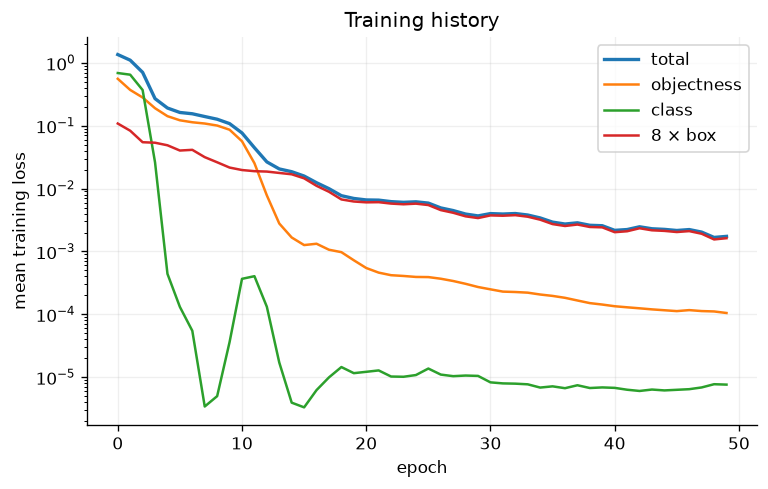

In [16]:
model.eval()
with torch.no_grad():
    test_raw = model(X_test)
    test_objectness = test_raw[:, 0].sigmoid()
    test_boxes = test_raw[:, 1:5].sigmoid()
    test_classes = test_raw[:, 5:].argmax(dim=1)

positive_test = y_obj_test.bool()
object_accuracy = ((test_objectness >= 0.5) == positive_test).float().mean()
class_accuracy = (test_classes[positive_test] == y_cls_test[positive_test]).float().mean()
test_iou = aligned_iou_xyxy(
    cxcywh_to_xyxy(test_boxes[positive_test]),
    cxcywh_to_xyxy(y_box_test[positive_test]),
)

print(f"test objectness accuracy: {object_accuracy:.3f}")
print(f"test class accuracy:      {class_accuracy:.3f}")
print(f"test mean IoU:            {test_iou.mean():.3f}")
print(f"test median IoU:          {test_iou.median():.3f}")

assert object_accuracy > 0.95
assert class_accuracy > 0.95
assert test_iou.mean() > 0.65

fig, ax = plt.subplots(figsize=(7.2, 4.2))
for name, values in history.items():
    ax.plot(values, label=name, lw=2 if name == "total" else 1.5)
ax.set(xlabel="epoch", ylabel="mean training loss", title="Training history", yscale="log")
ax.grid(alpha=0.2)
ax.legend()
plt.show()

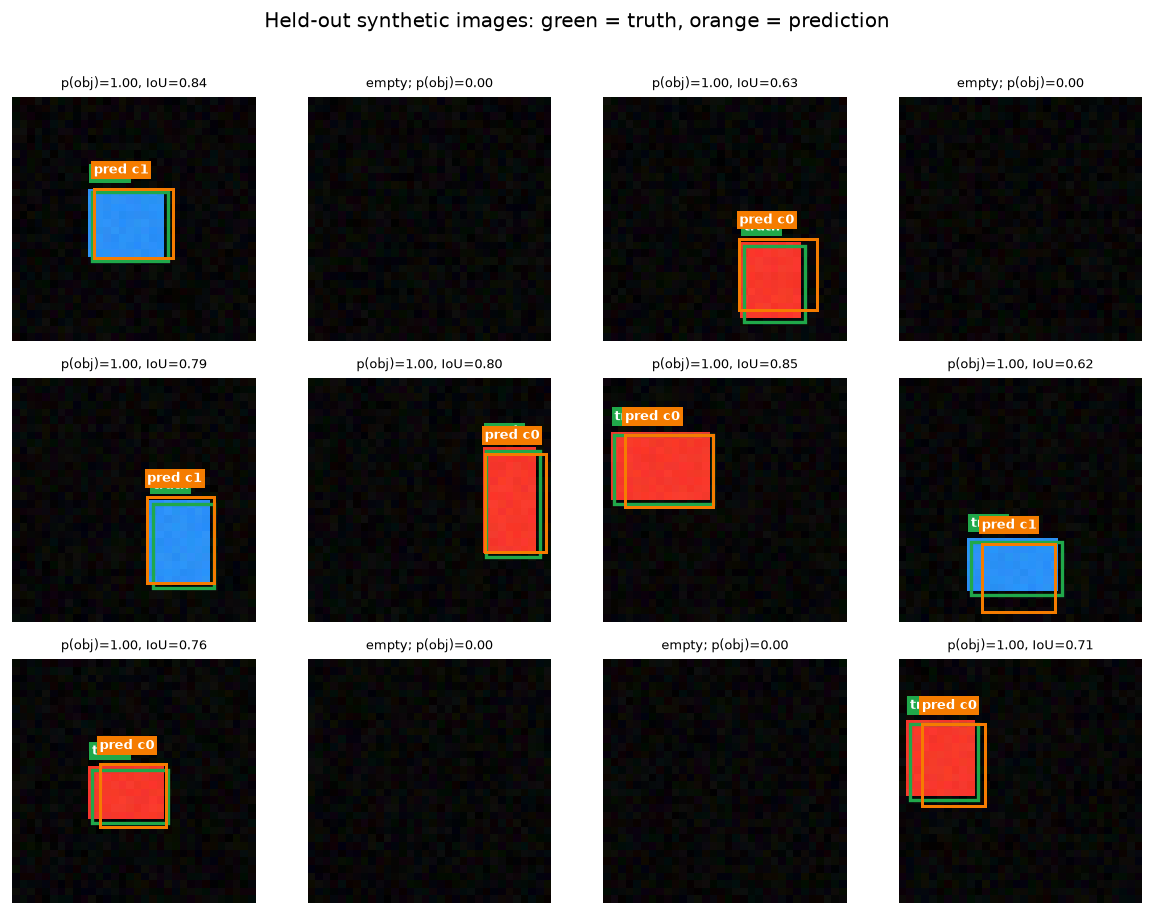

In [17]:
def normalized_cxcywh_to_pixels(box):
    return cxcywh_to_xyxy(box) * torch.tensor(
        [IMAGE_SIZE, IMAGE_SIZE, IMAGE_SIZE, IMAGE_SIZE], dtype=torch.float32
    )


fig, axes = plt.subplots(3, 4, figsize=(10, 7.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].permute(1, 2, 0))
    truth_present = bool(y_obj_test[i])
    prediction_present = bool(test_objectness[i] >= 0.5)

    if truth_present:
        truth_box = normalized_cxcywh_to_pixels(y_box_test[i]).unsqueeze(0)
        draw_boxes(ax, truth_box, ["truth"], [GREEN], linewidth=2.0)
    if prediction_present:
        prediction_box = normalized_cxcywh_to_pixels(test_boxes[i]).unsqueeze(0)
        predicted_name = f"pred c{int(test_classes[i])}"
        draw_boxes(ax, prediction_box, [predicted_name], [ORANGE], linewidth=1.8)

    if truth_present:
        sample_iou = aligned_iou_xyxy(
            cxcywh_to_xyxy(test_boxes[i:i+1]),
            cxcywh_to_xyxy(y_box_test[i:i+1]),
        ).item()
        subtitle = f"p(obj)={test_objectness[i]:.2f}, IoU={sample_iou:.2f}"
    else:
        subtitle = f"empty; p(obj)={test_objectness[i]:.2f}"
    ax.set_title(subtitle, fontsize=8)
    ax.axis("off")

fig.suptitle("Held-out synthetic images: green = truth, orange = prediction", y=1.01)
plt.tight_layout()
plt.show()

### What this model demonstrates—and what it omits

The model learned object presence, class, and location jointly. It also exposes the limitation of a one-record head: two objects cannot be represented simultaneously.

A practical detector adds several components:

- multiple spatial records ($K>1$), often arranged over one or more feature maps;
- an assignment rule for several objects and candidate locations;
- multiscale features for small and large objects;
- decoding and clipping of predicted boxes;
- score thresholding and NMS, or a set-based alternative;
- evaluation over classes, images, and IoU thresholds.

The synthetic classes are deliberately easy to distinguish by colour. This keeps the experiment focused on the detection pipeline, not feature learning from a large image collection.

## 9. Exercises and extensions

1. **Coordinate test.** Add random horizontal flips to `make_detection_dataset`. Transform the normalized $x_c$ target correctly and verify the round trip.
2. **A harder visual task.** Give both classes the same colour, but make class 0 square and class 1 rectangular. Retrain and compare class accuracy.
3. **Localization loss.** Replace smooth $L_1$ with GIoU loss. Check whether mean test IoU changes across three random seeds.
4. **Multiple records.** Change the head to produce a $2\times2$ grid. Define which cell owns an object's centre and construct the corresponding objectness mask.
5. **Imbalance.** Set `empty_probability=0.90`. Inspect objectness precision and recall rather than accuracy alone. Try a positive-class weight or focal loss.
6. **Post-processing.** Construct duplicate predictions from the trained box, apply the NMS function, and study the threshold sensitivity.
7. **Evaluation.** Build a test-set ranked list using $p(object)\,p(class\mid object)$. Compute AP for each class at IoU thresholds 0.50 and 0.75.

For each extension, state the box convention, tensor shape, assignment rule, and evaluation threshold before interpreting the result.

## Summary

- Detection predicts a variable-size set of class-and-box records.
- Box coordinates are meaningful only when their format, origin, scale, and edge convention are specified.
- IoU evaluates overlap; coordinate and IoU-family losses provide different training signals.
- In a $K\times(C+5)$ teaching tensor, $K$ is the number of reserved records, $C$ is the number of foreground classes, and $5=1$ objectness value $+4$ box values.
- Assignment determines supervision during training. Class-aware NMS removes within-image, within-class duplicates during inference. A deployment threshold selects one operating point; AP evaluates a broad ranked list. These are separate operations.
- A small PyTorch model can learn objectness, class, and location jointly, but multiple objects require multiple records and an assignment strategy.